# DINO Food Pretraining: SmartRecipe+ Unsupervised Component

**Workflow:**
1. Mount Google Drive (checkpoint persistence across disconnects)
2. Clone repo & install dependencies
3. Verify data pipeline
4. Train ResNet-50
5. Train ViT-S/16
6. Export weights & run evaluation

## 1. GPU Check & Drive Mount

In [ ]:
# Verify GPU is available
import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")

GPU: NVIDIA L4
VRAM: 23.7 GB
PyTorch: 2.10.0+cu128
CUDA: 12.8


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# DRIVE_BASE matches the auto-save path in pretrain.py:
#   save_to_drive → /content/drive/MyDrive/dino_checkpoints/{backbone}/epoch_XXXX.pth
DRIVE_BASE = '/content/drive/MyDrive/dino_checkpoints'
DRIVE_EXPORTS = f'{DRIVE_BASE}/exports'

os.makedirs(f'{DRIVE_BASE}/resnet50', exist_ok=True)
os.makedirs(f'{DRIVE_BASE}/vit_small_patch16_224', exist_ok=True)
os.makedirs(DRIVE_EXPORTS, exist_ok=True)
print(f'Checkpoint dir: {DRIVE_BASE}')
print(f'Exports dir:    {DRIVE_EXPORTS}')

Mounted at /content/drive
Checkpoint dir: /content/drive/MyDrive/dino_checkpoints
Exports dir:    /content/drive/MyDrive/dino_checkpoints/exports


## 2. Clone Repo & Install Dependencies

In [45]:
# Clone repo
%cd /content
!rm -rf smartrecipeplus  # clean slate on reconnect
!git clone https://github.com/jeanvelezdata/smartrecipeplus.git
%cd /content/smartrecipeplus/unsupervised

/content
Cloning into 'smartrecipeplus'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 92 (delta 34), reused 87 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (92/92), 34.55 KiB | 6.91 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/smartrecipeplus/unsupervised


In [ ]:
# Install dependencies
!pip install -q timm datasets PyYAML tqdm scikit-learn

## 3. Verify Data Pipeline

In [ ]:
# Download Food-101 and verify
!python data/prepare_food101.py --verify

Traceback (most recent call last):
  File "/content/smartrecipeplus/unsupervised/data/prepare_food101.py", line 166, in <module>
    _verify()
  File "/content/smartrecipeplus/unsupervised/data/prepare_food101.py", line 134, in _verify
    dataset = get_local_images(data_dir="/content/food101_images")
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/smartrecipeplus/unsupervised/data/prepare_food101.py", line 122, in get_local_images
    dataset = LocalImageDataset(data_dir)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/smartrecipeplus/unsupervised/data/prepare_food101.py", line 95, in __init__
    raise FileNotFoundError(
FileNotFoundError: No image files found under '/content/food101_images'. Supported extensions: {'.webp', '.jpeg', '.png', '.jpg'}


In [ ]:
import os, torchvision

DATA_DIR = '/content/food101_images'

if os.path.isdir(DATA_DIR) and len(os.listdir(DATA_DIR)) > 100_000:
    print(f'Already have images at {DATA_DIR}, skipping download.')
else:
    train_ds = torchvision.datasets.Food101(root='/content/food101_raw', split='train',  download=True)
    val_ds   = torchvision.datasets.Food101(root='/content/food101_raw', split='test',   download=True)

    os.makedirs(DATA_DIR, exist_ok=True)
    idx = 0
    for ds in (train_ds, val_ds):
        for img, _ in ds:
            img.save(f'{DATA_DIR}/{idx:06d}.jpg')
            idx += 1
        print(f'  ... {idx:,} images saved so far')

    print(f'Done, {idx:,} images saved to {DATA_DIR}')

print(f'Image count: {len(os.listdir(DATA_DIR)):,}')

100%|██████████| 5.00G/5.00G [03:51<00:00, 21.6MB/s]


  ... 75,750 images saved so far
  ... 101,000 images saved so far
Done, 101,000 images saved to /content/food101_images
Image count: 101,000


In [ ]:
import glob, os

# pretrain.py saves checkpoints
drive_ckpts = sorted(glob.glob(f'{DRIVE_BASE}/resnet50/epoch_*.pth'))
resume_flag = f'--resume {drive_ckpts[-1]}' if drive_ckpts else ''

if resume_flag:
    print(f'Resuming from: {drive_ckpts[-1]}')
else:
    print('Starting fresh, no previous checkpoint found.')

Resuming from: /content/drive/MyDrive/dino_checkpoints/resnet50/epoch_0030.pth


In [ ]:
# Train ResNet-50 with DINO
!python pretrain.py \
    --config configs/resnet50.yaml \
    --data-dir {DATA_DIR} \
    {resume_flag}

Device: cuda
[LocalImageDataset] Found 101,000 images under '/content/food101_images'
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 230MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Checkpoint loaded: /content/drive/MyDrive/dino_checkpoints/resnet50/epoch_0030.pth  (epoch 29)
Resumed from epoch 29
Training complete.


In [32]:
import shutil

local_ckpts = sorted(glob.glob('./checkpoints/resnet50/epoch_*.pth'))
if local_ckpts:
    dest = f'{DRIVE_BASE}/resnet50/{os.path.basename(local_ckpts[-1])}'
    shutil.copy2(local_ckpts[-1], dest)
    print(f'Backed up to Drive: {dest}')
else:
    print('No local checkpoints found.')

No local checkpoints found.


In [33]:
# Copy final ResNet-50 checkpoint to Drive
import shutil
local_ckpts = sorted(glob.glob('./checkpoints/resnet50/checkpoint_*.pth'))
if local_ckpts:
    dest = f'{DRIVE_BASE}/resnet50/{os.path.basename(local_ckpts[-1])}'
    shutil.copy2(local_ckpts[-1], dest)
    print(f'Saved to Drive: {dest}')

In [ ]:
# cfg["backbone"] for ViT is "vit_small_patch16_224"
drive_ckpts_vit = sorted(glob.glob(f'{DRIVE_BASE}/vit_small_patch16_224/epoch_*.pth'))
resume_flag_vit = f'--resume {drive_ckpts_vit[-1]}' if drive_ckpts_vit else ''

if resume_flag_vit:
    print(f'Resuming from: {drive_ckpts_vit[-1]}')
else:
    print('Starting fresh — no previous checkpoint found.')

Resuming from: /content/drive/MyDrive/dino_checkpoints/vit_small_patch16_224/epoch_0030.pth


In [ ]:
# Train ViT-Small/16 with DINO
!python pretrain.py \
    --config configs/vit_small16.yaml \
    --data-dir {DATA_DIR}\
    {resume_flag_vit}

Device: cuda
[LocalImageDataset] Found 101,000 images under '/content/food101_images'
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Checkpoint loaded: /content/drive/MyDrive/dino_checkpoints/vit_small_patch16_224/epoch_0030.pth  (epoch 29)
Resumed from epoch 29
Training complete.


In [29]:
local_ckpts_vit = sorted(glob.glob('./checkpoints/vit_small_patch16_224/epoch_*.pth'))
if local_ckpts_vit:
    dest = f'{DRIVE_BASE}/vit_small_patch16_224/{os.path.basename(local_ckpts_vit[-1])}'
    shutil.copy2(local_ckpts_vit[-1], dest)
    print(f'Backed up to Drive: {dest}')
else:
    print('No local checkpoints found.')

No local checkpoints found.


In [31]:
# Copy final ViT checkpoint to Drive
local_ckpts_vit = sorted(glob.glob('./checkpoints/vit_small_patch16_224/checkpoint_*.pth'))
if local_ckpts_vit:
    dest = f'{DRIVE_BASE}/vit_small_patch16_224/{os.path.basename(local_ckpts_vit[-1])}'
    shutil.copy2(local_ckpts_vit[-1], dest)
    print(f'Saved to Drive: {dest}')

In [35]:
resnet_ckpts = sorted(glob.glob(f'{DRIVE_BASE}/resnet50/epoch_*.pth'))
vit_ckpts    = sorted(glob.glob(f'{DRIVE_BASE}/vit_small_patch16_224/epoch_*.pth'))

if not resnet_ckpts:
    raise FileNotFoundError(f'No ResNet-50 checkpoints found in {DRIVE_BASE}/resnet50/')
if not vit_ckpts:
    raise FileNotFoundError(f'No ViT checkpoints found in {DRIVE_BASE}/vit_small_patch16_224/')

resnet_ckpt = resnet_ckpts[-1]
vit_ckpt    = vit_ckpts[-1]
print(f'ResNet-50 checkpoint: {resnet_ckpt}')
print(f'ViT-S/16 checkpoint:  {vit_ckpt}')

ResNet-50 checkpoint: /content/drive/MyDrive/dino_checkpoints/resnet50/epoch_0030.pth
ViT-S/16 checkpoint:  /content/drive/MyDrive/dino_checkpoints/vit_small_patch16_224/epoch_0030.pth


In [36]:
# Export ResNet-50
!python export_weights.py \
    --checkpoint {resnet_ckpt} \
    --config configs/resnet50.yaml \
    --output {DRIVE_EXPORTS}/resnet50_food_dino.pth

# Export ViT-S/16
!python export_weights.py \
    --checkpoint {vit_ckpt} \
    --config configs/vit_small16.yaml \
    --output {DRIVE_EXPORTS}/vit_small16_food_dino.pth

print(f'\nExported weights saved to: {DRIVE_EXPORTS}')
!ls -lh {DRIVE_EXPORTS}/

Loading checkpoint from: /content/drive/MyDrive/dino_checkpoints/resnet50/epoch_0030.pth
Backbone:           resnet50
Number of keys:     318
Number of params:   23,561,205
Stripped keys:      ['student_head', 'teacher_backbone', 'teacher_head', 'optimizer', 'center', 'loss', 'epoch', 'config']

Exported backbone weights saved to: /content/drive/MyDrive/dino_checkpoints/exports/resnet50_food_dino.pth

--- Load with torchvision ---
import torchvision, torch
model = torchvision.models.resnet50()
model.load_state_dict(torch.load("/content/drive/MyDrive/dino_checkpoints/exports/resnet50_food_dino.pth"), strict=False)
Loading checkpoint from: /content/drive/MyDrive/dino_checkpoints/vit_small_patch16_224/epoch_0030.pth
Backbone:           vit_small_patch16_224
Number of keys:     150
Number of params:   21,665,664
Stripped keys:      ['student_head', 'teacher_backbone', 'teacher_head', 'optimizer', 'center', 'loss', 'epoch', 'config']

Exported backbone weights saved to: /content/drive/MyDri

## 7. Evaluate through Linear Probe

In [37]:
# Linear probe: ResNet-50
!python evaluate.py \
    --checkpoint {resnet_ckpt} \
    --config configs/resnet50.yaml \
    --eval-type linear_probe

Device: cuda
Backbone: resnet50  |  eval-type: linear_probe

  Linear Probe Evaluation

[1/2] Training linear probe — Food-DINO pretrained encoder...
Loaded teacher backbone weights from /content/drive/MyDrive/dino_checkpoints/resnet50/epoch_0030.pth
README.md: 16.4kB [00:00, 9.42MB/s]
data/train-00000-of-00008.parquet: 100% 490M/490M [00:02<00:00, 174MB/s]
data/train-00001-of-00008.parquet: 100% 464M/464M [00:01<00:00, 256MB/s]
data/train-00002-of-00008.parquet: 100% 472M/472M [00:01<00:00, 261MB/s]
data/train-00003-of-00008.parquet: 100% 464M/464M [00:03<00:00, 122MB/s]
data/train-00004-of-00008.parquet: 100% 475M/475M [00:02<00:00, 215MB/s]
data/train-00005-of-00008.parquet: 100% 470M/470M [00:02<00:00, 180MB/s]
data/train-00006-of-00008.parquet: 100% 478M/478M [00:03<00:00, 132MB/s]
data/train-00007-of-00008.parquet: 100% 486M/486M [00:02<00:00, 220MB/s]
data/validation-00000-of-00003.parquet: 100% 423M/423M [00:01<00:00, 234MB/s] 
data/validation-00001-of-00003.parquet: 100% 413M/

In [38]:
# Linear probe: ViT-S/16
!python evaluate.py \
    --checkpoint {vit_ckpt} \
    --config configs/vit_small16.yaml \
    --eval-type linear_probe

Device: cuda
Backbone: vit_small_patch16_224  |  eval-type: linear_probe

  Linear Probe Evaluation

[1/2] Training linear probe — Food-DINO pretrained encoder...
Loaded teacher backbone weights from /content/drive/MyDrive/dino_checkpoints/vit_small_patch16_224/epoch_0030.pth
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncat

## 8. Evaluate through Visualizations

Device: cuda
Backbone: resnet50  |  eval-type: tsne

  t-SNE Visualisation
Loaded teacher backbone weights from /content/drive/MyDrive/dino_checkpoints/resnet50/epoch_0030.pth
Extracting features from 5000 images...
Running t-SNE (perplexity=30) on 5000 × 2048-dim feature vectors...
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
Saved tsne_visualization.png



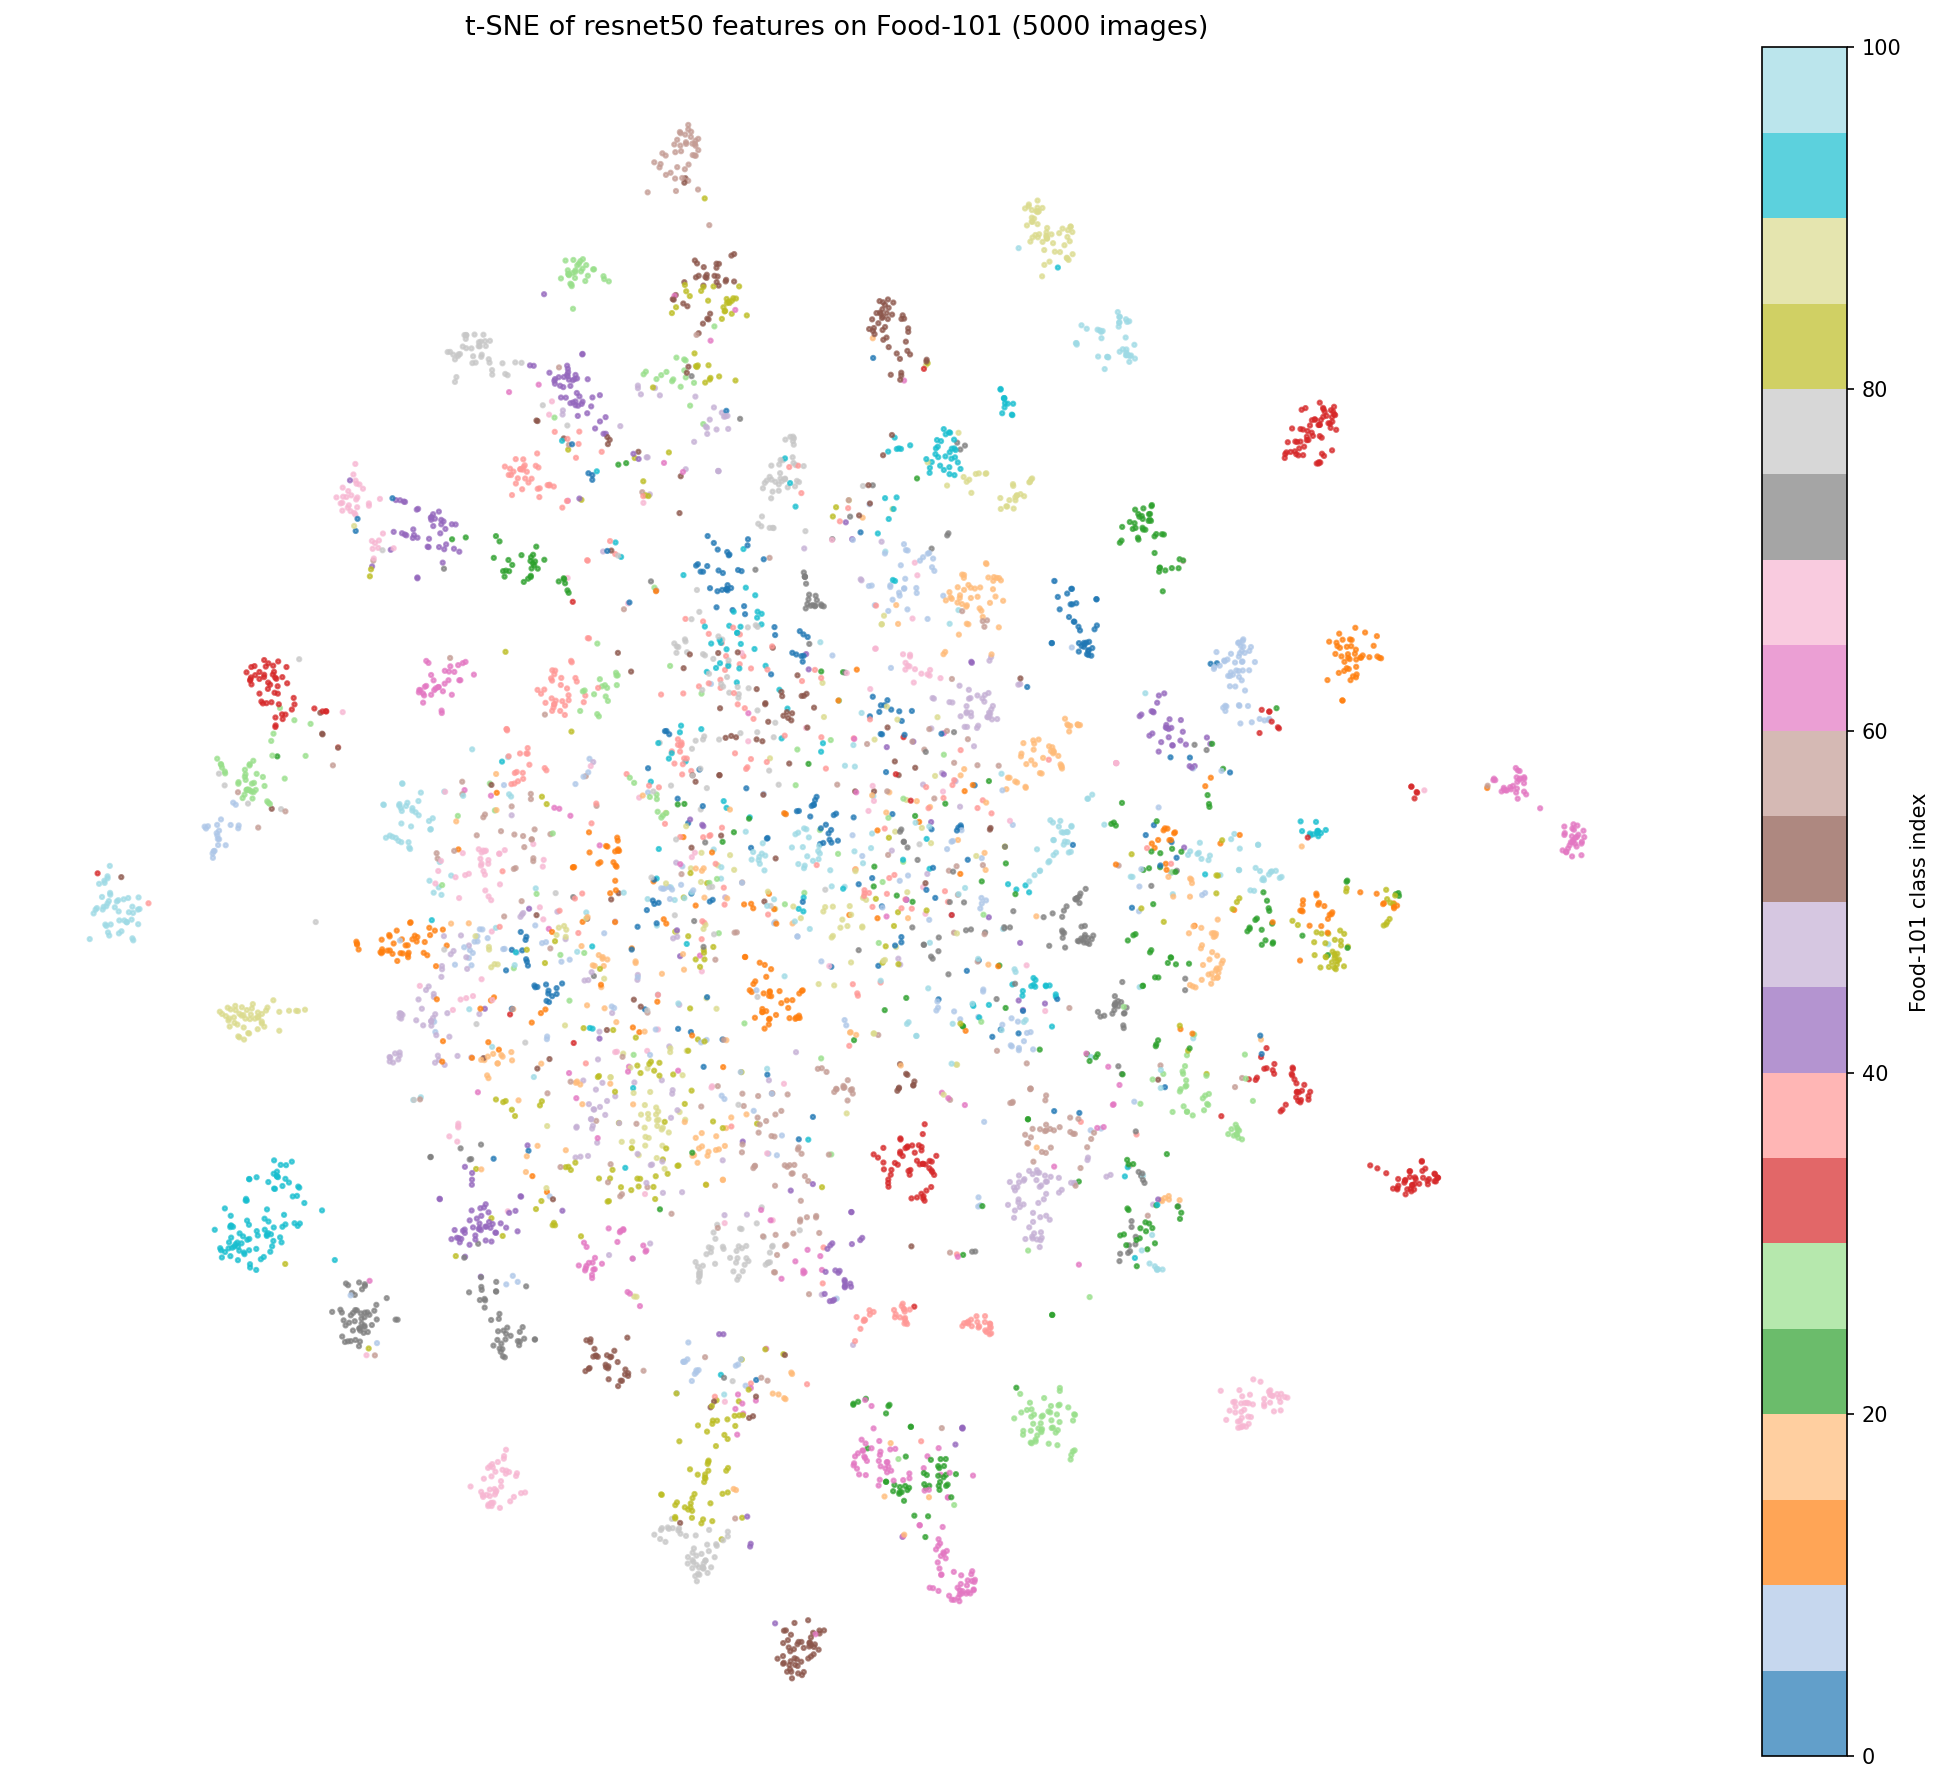

In [48]:
# t-SNE visualization
!python evaluate.py \
    --checkpoint {resnet_ckpt} \
    --config configs/resnet50.yaml \
    --eval-type tsne

# Display the plot inline
from IPython.display import Image, display
display(Image('tsne_visualization.png'))

In [49]:
for f in ['tsne_visualization.png', 'attention_maps.png']:
    if os.path.exists(f):
        shutil.copy2(f, f'{DRIVE_EXPORTS}/{f}')
        print(f'Saved {f} to Drive')

# Copy training logs from both runs
for log in ['./checkpoints/resnet50/training_log.csv', './checkpoints/vit_small_patch16_224/training_log.csv']:
    if os.path.exists(log):
        name = os.path.basename(os.path.dirname(log)) + '_training_log.csv'
        shutil.copy2(log, f'{DRIVE_EXPORTS}/{name}')
        print(f'Saved {name} to Drive')

print(f'\nAll outputs in: {DRIVE_EXPORTS}')
!ls -lh {DRIVE_EXPORTS}/

Saved tsne_visualization.png to Drive

All outputs in: /content/drive/MyDrive/dino_checkpoints/exports
total 174M
-rw------- 1 root root  90M Mar 27 13:43 resnet50_food_dino.pth
-rw------- 1 root root   40 Mar 27 13:27 resnet50_training_log.csv
-rw------- 1 root root 588K Mar 27 21:57 tsne_visualization.png
-rw------- 1 root root  83M Mar 27 13:43 vit_small16_food_dino.pth


In [50]:
# Copy evaluation outputs to Drive
for f in ['tsne_visualization.png', 'attention_maps.png', 'training_log.csv']:
    if os.path.exists(f):
        shutil.copy2(f, f'{DRIVE_BASE}/exports/{f}')
        print(f'Saved {f} to Drive')

print(f'\nAll outputs in: {DRIVE_BASE}/exports/')
!ls -lh {DRIVE_BASE}/exports/

Saved tsne_visualization.png to Drive

All outputs in: /content/drive/MyDrive/dino_checkpoints/exports/
total 174M
-rw------- 1 root root  90M Mar 27 13:43 resnet50_food_dino.pth
-rw------- 1 root root   40 Mar 27 13:27 resnet50_training_log.csv
-rw------- 1 root root 588K Mar 27 21:57 tsne_visualization.png
-rw------- 1 root root  83M Mar 27 13:43 vit_small16_food_dino.pth


In [51]:
import torch
import torchvision.models as models
import timm

# Test ResNet-50 loading
resnet = models.resnet50()
state = torch.load(f'{DRIVE_EXPORTS}/resnet50_food_dino.pth', map_location='cpu')
resnet.load_state_dict(state, strict=False)
print(f'ResNet-50 loaded — {sum(p.numel() for p in resnet.parameters())/1e6:.1f}M params')

# Test ViT-S/16 loading
vit = timm.create_model('vit_small_patch16_224', pretrained=False)
state = torch.load(f'{DRIVE_EXPORTS}/vit_small16_food_dino.pth', map_location='cpu')
vit.load_state_dict(state, strict=False)
print(f'ViT-S/16 loaded — {sum(p.numel() for p in vit.parameters())/1e6:.1f}M params')

# Quick forward pass
dummy = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    print(f'ResNet-50 output shape: {resnet(dummy).shape}')
    print(f'ViT-S/16 output shape:  {vit(dummy).shape}')

print('\nPass.')

ResNet-50 loaded — 25.6M params
ViT-S/16 loaded — 22.1M params
ResNet-50 output shape: torch.Size([1, 1000])
ViT-S/16 output shape:  torch.Size([1, 1000])

Pass.


In [52]:
import torch
import torchvision.models as models
import timm

# Test ResNet-50 loading
resnet = models.resnet50()
state = torch.load(f'{DRIVE_BASE}/exports/resnet50_food_dino.pth', map_location='cpu')
resnet.load_state_dict(state, strict=False)
print(f'ResNet-50 loaded — {sum(p.numel() for p in resnet.parameters())/1e6:.1f}M params')

# Test ViT-S/16 loading
vit = timm.create_model('vit_small_patch16_224', pretrained=False)
state = torch.load(f'{DRIVE_BASE}/exports/vit_small16_food_dino.pth', map_location='cpu')
vit.load_state_dict(state, strict=False)
print(f'ViT-S/16 loaded — {sum(p.numel() for p in vit.parameters())/1e6:.1f}M params')

# Quick forward pass
dummy = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    print(f'ResNet-50 output shape: {resnet(dummy).shape}')
    print(f'ViT-S/16 output shape:  {vit(dummy).shape}')

print('\nPass.')

ResNet-50 loaded — 25.6M params
ViT-S/16 loaded — 22.1M params
ResNet-50 output shape: torch.Size([1, 1000])
ViT-S/16 output shape:  torch.Size([1, 1000])

Pass.


## 9. Extract Feature Embeddings

In [40]:
DRIVE_EMBEDDINGS = f'{DRIVE_BASE}/embeddings'
os.makedirs(DRIVE_EMBEDDINGS, exist_ok=True)

!python extract_embeddings.py \
    --checkpoint {resnet_ckpt} \
    --config configs/resnet50.yaml \
    --splits train val \
    --kmeans 101 \
    --output-dir ./embeddings/resnet50 \
    --batch-size 256

Device:   cuda
Backbone: resnet50  (embed_dim=2048)
Splits:   ['train', 'val']
Loaded teacher backbone from /content/drive/MyDrive/dino_checkpoints/resnet50/epoch_0030.pth  (epoch 29)

  Extracting embeddings — train split
  Dataset size: 75750 images
  5120/75750 images processed
  10240/75750 images processed
  15360/75750 images processed
  20480/75750 images processed
  25600/75750 images processed
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
  30720/75750 images processed
  35840/75750 images processed
  40960/75750 images processed
  46080/75750 images processed
  51200/75750 images processed
  56320/75750 images processed
  61440/75750 images processed
  66560/75750 images processed
  71680/75750 images processed
  75750/75750 images processed
  Embeddings shape: (75750, 2048)  dtype: float32
  Fitting k-means (k=101) on 75750 L2-normalised embeddings...
  k-means inertia: 40150.58
  Saved: ./embed

In [41]:
!python extract_embeddings.py \
    --checkpoint {vit_ckpt} \
    --config configs/vit_small16.yaml \
    --splits train val \
    --kmeans 101 \
    --output-dir ./embeddings/vit_small16 \
    --batch-size 256


Device:   cuda
Backbone: vit_small_patch16_224  (embed_dim=384)
Splits:   ['train', 'val']
Loaded teacher backbone from /content/drive/MyDrive/dino_checkpoints/vit_small_patch16_224/epoch_0030.pth  (epoch 29)

  Extracting embeddings — train split
  Dataset size: 75750 images
  5120/75750 images processed
  10240/75750 images processed
  15360/75750 images processed
  20480/75750 images processed
  25600/75750 images processed
/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
  30720/75750 images processed
  35840/75750 images processed
  40960/75750 images processed
  46080/75750 images processed
  51200/75750 images processed
  56320/75750 images processed
  61440/75750 images processed
  66560/75750 images processed
  71680/75750 images processed
  75750/75750 images processed
  Embeddings shape: (75750, 384)  dtype: float32
  Fitting k-means (k=101) on 75750 L2-normalised embeddings...
  k-means inertia: 3

In [43]:
for npz in glob.glob('./embeddings/**/*.npz', recursive=True):
    dest = f'{DRIVE_EMBEDDINGS}/{os.path.basename(npz)}'
    shutil.copy2(npz, dest)
    size_mb = os.path.getsize(dest) / 1e6
    print(f'Saved {os.path.basename(npz)}  ({size_mb:.1f} MB)  →  {dest}')

print(f'\nAll embeddings in: {DRIVE_EMBEDDINGS}')
!ls -lh {DRIVE_EMBEDDINGS}/


Saved vit_small_patch16_224_val_embeddings.npz  (36.1 MB)  →  /content/drive/MyDrive/dino_checkpoints/embeddings/vit_small_patch16_224_val_embeddings.npz
Saved vit_small_patch16_224_train_embeddings.npz  (108.3 MB)  →  /content/drive/MyDrive/dino_checkpoints/embeddings/vit_small_patch16_224_train_embeddings.npz
Saved resnet50_val_embeddings.npz  (113.4 MB)  →  /content/drive/MyDrive/dino_checkpoints/embeddings/resnet50_val_embeddings.npz
Saved resnet50_train_embeddings.npz  (342.3 MB)  →  /content/drive/MyDrive/dino_checkpoints/embeddings/resnet50_train_embeddings.npz

All embeddings in: /content/drive/MyDrive/dino_checkpoints/embeddings
total 573M
-rw------- 1 root root 327M Mar 27 21:46 resnet50_train_embeddings.npz
-rw------- 1 root root 109M Mar 27 21:47 resnet50_val_embeddings.npz
-rw------- 1 root root 104M Mar 27 21:50 vit_small_patch16_224_train_embeddings.npz
-rw------- 1 root root  35M Mar 27 21:51 vit_small_patch16_224_val_embeddings.npz


In [44]:
import numpy as np

for backbone, dim in [('resnet50', 2048), ('vit_small_patch16_224', 384)]:
    for split in ['train', 'val']:
        path = f'{DRIVE_EMBEDDINGS}/{backbone}_{split}_embeddings.npz'
        data = np.load(path)
        emb = data['embeddings']
        lbl = data['labels']
        assert emb.dtype == np.float32,          f'Expected float32, got {emb.dtype}'
        assert emb.shape[1] == dim,              f'Expected dim {dim}, got {emb.shape[1]}'
        assert lbl.shape[0] == emb.shape[0],     'embeddings/labels length mismatch'
        assert lbl.min() >= 0 and lbl.max() <= 100, 'label out of Food-101 range'
        cluster_info = f'  clusters: {len(set(data["cluster_ids"]))}' if 'cluster_ids' in data else ''
        print(f'{backbone} [{split}]  shape: {emb.shape}  labels: {lbl.shape}{cluster_info}')

print('\nAll embedding files verified.')

resnet50 [train]  shape: (75750, 2048)  labels: (75750,)  clusters: 101
resnet50 [val]  shape: (25250, 2048)  labels: (25250,)  clusters: 101
vit_small_patch16_224 [train]  shape: (75750, 384)  labels: (75750,)  clusters: 101
vit_small_patch16_224 [val]  shape: (25250, 384)  labels: (25250,)  clusters: 101

All embedding files verified.
